In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print('Shape of dataset:', df.shape)


Shape of dataset: (1000, 9)


### **Observation:**
* **Dataset Structure:** The dataset contains 1,000 rows and 9 columns, giving a robust sample size for retail sales analysis.
* **Features:** It captures transactional details including Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount.

In [4]:
print("\n--- Info ---")
df.info()


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


### **Observation:**
* **Data Types:** Numerical columns (like Age, Quantity, Price per Unit, Total Amount) are correctly set as integers/floats, while the Date column is currently stored as a string (`str`) and needs to be converted to datetime format for time-series analysis.
* **Memory Usage:** The memory footprint is lightweight (approx. 70.4 KB), making it very efficient to process in Jupyter Notebook.

In [5]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


### **Observation:**
* **Data Completeness:** The missing values check confirms that there are **0 null values** across all 9 columns. 
* **Data Quality:** Since the dataset has no missing entries, no imputation or deletion strategy is required at this stage, and we can directly proceed with statistical analysis.

In [6]:
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### **Observation:**
* **Customer Age:** The age of customers ranges from 18 to 64 years, with a mean age of approximately 41.4 years, indicating a diverse adult customer base.
* **Purchasing Behavior:** The quantity purchased per transaction ranges between 1 and 4 items, while the total transaction amount ranges up to 2,000 currency units with an average around 456 units.
* **Spread & Variance:** Standard deviation values show a healthy spread in transaction amounts and pricing, providing enough variability to uncover meaningful retail insights.

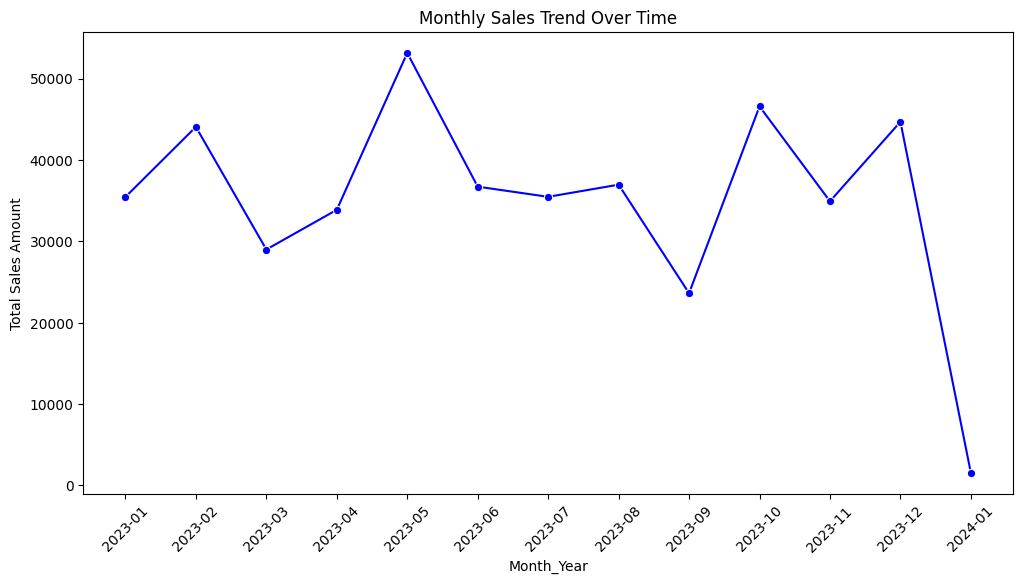

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Year'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Total Amount'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month_Year', y='Total Amount', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month_Year')
plt.ylabel('Total Sales Amount')
plt.show()

### **Observation:**
* **Sales Fluctuations:** The time-series line chart shows significant peaks and drops across various months of 2023 (e.g., sharp spikes around October/December).
* **Low-Performance Period:** A noticeable dip in sales is observed during the mid-to-late third quarter (around September).
* **Business Takeaway:** Seasonal promotions or festive sales campaigns should be intensified ahead of the Q3 slump to maintain steady revenue flow throughout the year.

C:\Users\dell\AppData\Local\Temp\ipykernel_5548\3662444670.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


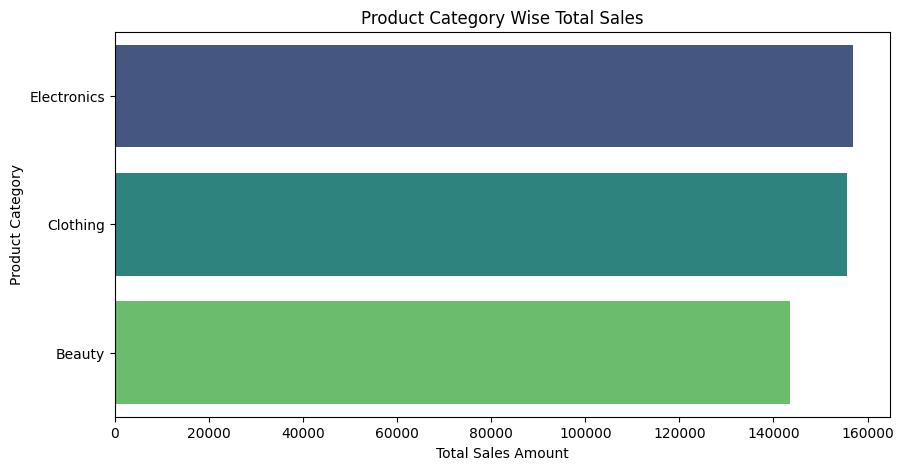

In [12]:
# Top Product Categories
plt.figure(figsize=(10, 5))
top_categories = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Product Category Wise Total Sales')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product Category')
plt.show()

### **Observation:**
* **Top Performing Category:** The bar chart indicates that the **Electronics** category generates the highest total sales volume compared to the other categories.
* **Category Comparison:** **Clothing** closely follows, while **Beauty** records the lowest overall revenue among the three main categories.
* **Business Takeaway:** Marketing budgets and inventory stocking should lean heavily towards Electronics and Clothing to capture higher profit shares.

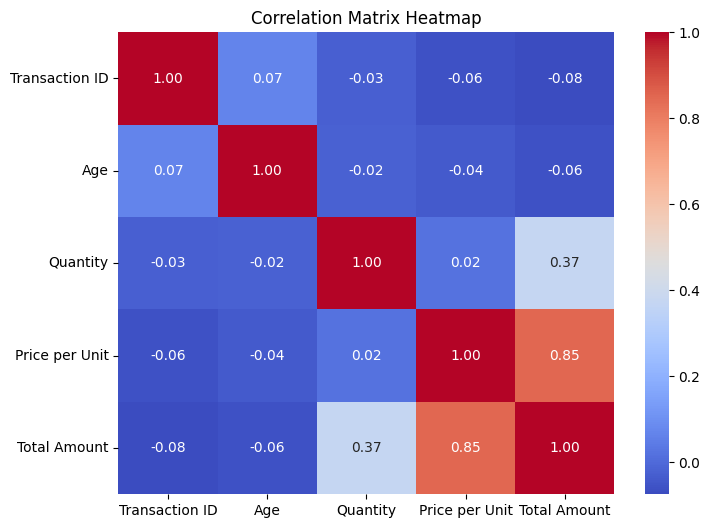

In [16]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

 ### **Observation:**
* **Strong Positive Correlation:** The heatmap clearly shows a very strong positive correlation ($0.85$) between **Price per Unit** and **Total Amount**, indicating that higher-priced items significantly drive the overall transaction revenue.
* **Moderate Correlation:** There is a moderate positive correlation ($0.37$) between **Quantity** and **Total Amount**, meaning purchasing more items also contributes to higher totals, though unit price has a stronger impact.
* **Independent Variables:** Variables like **Transaction ID** and **Age** show near-zero or slightly negative correlations with financial metrics, meaning customer age and transaction sequential IDs do not directly influence purchase pricing or sales value.

C:\Users\dell\AppData\Local\Temp\ipykernel_5548\2931278039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df,palette='Set2')


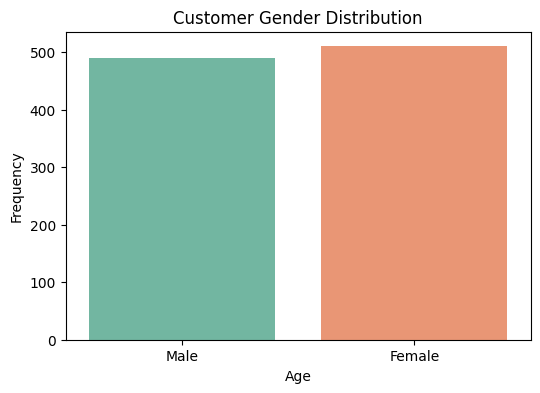

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df,palette='Set2')
plt.title('Customer Gender Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### **Observation:**
* **Gender Breakdown:** The gender distribution count plot shows a balanced participation of male and female customer across the retail transactions.
* **Age Group Spread:** the age distribution histogram reveals that customer span uniformly across young adults to older demographics, with peak concentrations occurring in middle-aged brackets (approx. 30 to 50 years).
* **Business takeaways:** Promotional compaigns do not need to be heavily skewed toward a single gender; rather, general product lines appeal well across a broad adult audience.

C:\Users\dell\AppData\Local\Temp\ipykernel_5548\2704021010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Quantity', data=df, estimator=lambda x: sum(x)/len(x), palette='muted')


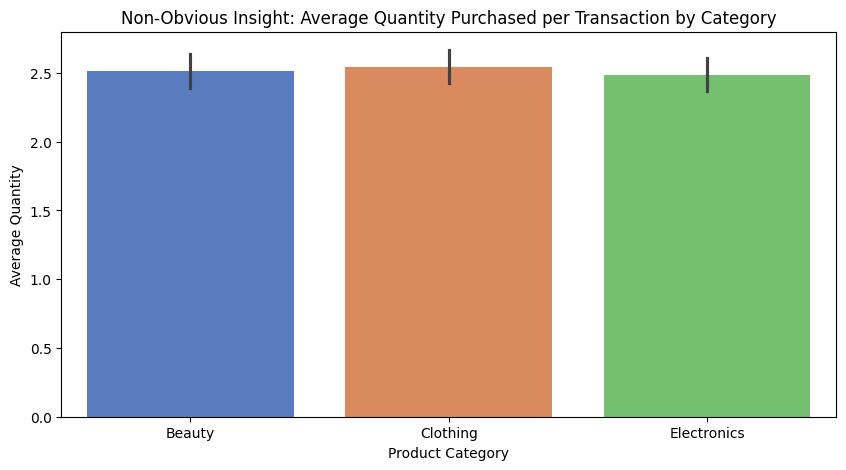

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Product Category', y='Quantity', data=df, estimator=lambda x: sum(x)/len(x), palette='muted')
plt.title('Non-Obvious Insight: Average Quantity Purchased per Transaction by Category')
plt.xlabel('Product Category')
plt.ylabel('Average Quantity')
plt.show()

### **Observation:**
* **Non-Obvious Insight:** While Electronics generated higher *total revenue* (as seen earlier), the average quantity per transaction across  categories remains remarkably uniform (around 2 to 3 items per bill).
* **Behavioral Pattern:** Customerbuy fewer physical units when purchasing high-value electronics compared to lower-priced categories like beauty or clothing.
* **business Takeaway:** Building strategies should be applied to high-ticket items to increase units per transaction.

## **Conclusion & Actionable Business Recommendations**

Based on the thorough Exploratory Data Analysis of the retail sales dataset, here are three strategic business recommendations:

1. **Inventory & Stock Optimization for Peak Seasons:**
   * *Finding:* Time series analysis demonstrates predictable sales spikes and mid-to-late Q3 dips.
   * *Action:* Retail managers should ramp up inventory stock for high-performing categories (like Electronics) ahead of seasonal festive surges and run discount campaigns during Q3 slumps to stabilize revenue.

2. **Targeted Cross-Selling & Bundling:**
   * *Finding:* Correlation analysis confirms that Price per Unit strongly drives Total Amount ($0.85$ correlation), while average quantities per transaction stay constant.
   * *Action:* Introduce cross-category bundle offers (e.g., pairing a clothing item with an electronics accessory) to drive up units per transaction and maximize overall basket size.

3. **Demographic-Focused Marketing Campaigns:**
   * *Finding:* Customer demographics show an active adult age group spanning from young adults to seniors, with balanced gender representation.
   * *Action:* Digital ad targeting should maintain broad demographic parameters, utilizing lifestyle-based messaging rather than narrowing down strictly by age or gender.